# Bending playground

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, Angle, AltAz, ICRS, EarthLocation
from astropy.coordinates import BaseCoordinateFrame, BaseRepresentation, CartesianRepresentation, SphericalRepresentation, UnitSphericalRepresentation

from astropy.coordinates import RepresentationMapping
import astropy.coordinates.representation as r
from astropy.coordinates import TimeAttribute, QuantityAttribute, EarthLocationAttribute
from erfa import ufunc as erfa_ufunc
from astropy.utils import classproperty
from astropy.coordinates.matrix_utilities import rotation_matrix
from astropy.coordinates.baseframe import frame_transform_graph

from astropy.coordinates.transformations import FunctionTransform, StaticMatrixTransform

from astropy.modeling.rotations import SphericalRotationSequence

from scipy.interpolate import CloughTocher2DInterpolator, RBFInterpolator, SmoothBivariateSpline
import scipy
scipy.__version__

import dill as pickle

from datetime import datetime
from datetime import timezone

In [ ]:
df = pd.read_csv("merged.csv")

az_deg = df["Az"].values
el_deg = df["El"].values

az = np.deg2rad(az_deg)
el = np.deg2rad(el_deg)

offset_az = df["Offset Az"].values
offset_el = df["Offset El"].values

N = len(df)


# ==========================================================
# Build interleaved design matrix
# ==========================================================

X = np.zeros((2*N, 8))

for i in range(N):

    X[2*i] = [
        1,
        0,
        np.tan(el[i]),
        -np.tan(el[i]) * np.sin(az[i]),
        -np.tan(el[i]) * np.cos(az[i]),
        0,
        np.cos(az[i]),
        np.sin(az[i])
    ]

    X[2*i+1] = [
        0,
        1,
        0,
        np.cos(az[i]),
        -np.sin(az[i]),
        np.cos(el[i]),
        0,
        0
    ]


print("Design Matrix Shape:", X.shape)
print(X)


# ==========================================================
# Build matching target vector
# ==========================================================

y = np.zeros(2*N)

for i in range(N):
    y[2*i] = offset_az[i]
    y[2*i+1] = offset_el[i]

print(y) #odd i = azimiuth offset, even i = elevation offset


# ==========================================================
# Solve least squares
# ==========================================================

coef, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print("\nCoefficients:")
print(coef)

# ==========================================================
# Prediction functions
# ==========================================================

def azfit_trig(az_deg, el_deg=None, grid=False):

    az = np.deg2rad(np.asarray(az_deg))

    return (
        coef[0]
        + coef[1] * 0
        + coef[2] * np.tan(el)
        - coef[3] * np.tan(el) * np.sin(az)
        - coef[4] * np.tan(el) * np.cos(az)
        + coef[5] * 0
        + coef[6] * np.cos(az)
        + coef[7] * np.sin(az)
    )


def altfit_trig(az_deg=None, el_deg=None, grid=False):

    el = np.deg2rad(np.asarray(el_deg))

    return (
        coef[1] * 0
        + coef[1]
        + coef[2] * 0
        + coef[3] * np.cos(az)
        - coef[4] * np.sin(az)
        + coef[5] * np.cos(el)
        + coef[6] * 0
        + coef[7] * 0
    )


Design Matrix Shape: (206, 8)
[[ 1.          0.          2.33298296 ...  0.          0.40462622
   0.91448216]
 [ 0.          1.          0.         ...  0.39396928  0.
   0.        ]
 [ 1.          0.          2.38579108 ...  0.          0.40736958
   0.91326339]
 ...
 [ 0.          1.          0.         ...  0.70249343  0.
   0.        ]
 [ 1.          0.          0.90112476 ...  0.          0.9648222
  -0.26290325]
 [ 0.          1.          0.         ...  0.74287853  0.
   0.        ]]
[ 0.067 -0.191  0.068 -0.192  0.066 -0.19   0.069 -0.189  0.071 -0.186
  0.073 -0.184  0.073 -0.183  0.072 -0.183  0.077 -0.179  0.075 -0.186
  0.075 -0.189  0.072 -0.193  0.07  -0.201  0.056 -0.221  0.042 -0.23
  0.023 -0.234  0.004 -0.24  -0.019 -0.248 -0.035 -0.251 -0.044 -0.246
 -0.059 -0.245 -0.067 -0.247 -0.073 -0.248 -0.077 -0.246 -0.079 -0.248
 -0.083 -0.248 -0.084 -0.249 -0.087 -0.25  -0.088 -0.25  -0.09  -0.254
 -0.091 -0.253 -0.092 -0.257 -0.094 -0.259 -0.096 -0.263 -0.097 -0.268
 -0.1  

In [ ]:
class bending_model:
    def __init__(self, altfit_func, azfit_func, model_name, model_description):
        self.alt_func = altfit_func
        self.az_func = azfit_func
        self.name = model_name
        self.description = model_description

    def astro_to_drive(self, astro_alt, astro_az):
        deg_alt = Angle(astro_alt*u.deg).wrap_at(180*u.deg).deg
        deg_az = Angle(astro_az*u.deg).wrap_at(360*u.deg).deg
        drive_alt = (astro_alt-self.alt_func(deg_az, deg_alt, grid=False))
        drive_az = (astro_az-self.az_func(deg_az, deg_alt, grid=False))
        return (drive_alt, drive_az)

    def drive_to_astro(self, drive_alt, drive_az):
        deg_alt = Angle(drive_alt*u.deg).wrap_at(180*u.deg).deg
        deg_az = Angle(drive_az*u.deg).wrap_at(360*u.deg).deg
        astro_alt = (drive_alt+self.alt_func(deg_az, deg_alt, grid=False))
        astro_az = (drive_az+self.az_func(deg_az, deg_alt, grid=False))
        return (astro_alt, astro_az)

    def delta(self, alt, az):
        deg_alt = Angle(alt*u.deg).wrap_at(180*u.deg).deg
        deg_az = Angle(az*u.deg).wrap_at(360*u.deg).deg
        delta_alt = self.alt_func(deg_az, deg_alt, grid=False)
        delta_az = self.az_func(deg_az, deg_alt, grid=False)
        return (delta_alt, delta_az)

In [ ]:
b = bending_model(
    altfit_func=altfit_trig,
    azfit_func=azfit_trig,
    model_name='testModel',
    model_description='blank'
)

"""
b = bending_model(altfit_func=altfit_spline,
                  azfit_func=azfit_spline,
                  model_name='test_model_v0',
                  model_description=f'generated on {datetime.now().strftime("%Y/%m/%d %H:%M:%S")} using toy data and scipy {scipy.__version__} SmoothBivariateSpline'
                 )
"""

'\nb = bending_model(altfit_func=altfit_spline,\n                  azfit_func=azfit_spline,\n                  model_name=\'test_model_v0\',\n                  model_description=f\'generated on {datetime.now().strftime("%Y/%m/%d %H:%M:%S")} using toy data and scipy {scipy.__version__} SmoothBivariateSpline\'\n                 )\n'

In [ ]:
##Chi squared test

#pred_alt = altfit_trig(df["El"].values)
#pred_az  = azfit_trig(df["Az"].values)
az = np.deg2rad(df["Az"].values)
el = np.deg2rad(df["El"].values)

az_pred = (coef[0] + coef[2]*np.tan(el) - coef[3]*np.tan(el)*np.sin(az)
- coef[4]*np.tan(el)*np. cos(az) + coef[6]*np. cos(az) + coef[7]*np.sin(az))

el_pred = coef[1] + coef[3]*np.cos(az) - coef[4]*np.sin(az) + coef[5]*np.cos(el)

df["Model Offset El"] = el_pred
df["Model Offset Az"] = az_pred

df["El Residual"] = df["Offset El"] - df["Model Offset El"]
df["Az Residual"] = df["Offset Az"] - df["Model Offset Az"]

chi2_el = np.sum(df["El Residual"]**2)
chi2_az = np.sum(df["Az Residual"]**2)
chi2_total = chi2_el + chi2_az

##sigma here is calculated to be variance of the residuals; later, consider variance in...
##fitted parameters
##predictions

"""
N = len(df)
p = 3  #parameters per axis
sigma_el = np.sqrt(np.sum(df["El Residual"]**2) / (N - p))
sigma_az = np.sqrt(np.sum(df["Az Residual"]**2) / (N - p))
print("Estimated sigma El:", sigma_el)
print("Estimated sigma Az:", sigma_az)
"""

print("Total Chi^2:", chi2_total)
print("Chi^2 El:", chi2_el)
print("Chi^2 Az:", chi2_az)

print("El RMS:", np.sqrt(np.mean(df["El Residual"]**2)))
print("Az RMS:", np.sqrt(np.mean(df["Az Residual"]**2)))
print("|d| RMS:", np.sqrt(np.mean(df["Az Residual"]**2)+ df["El Residual"]**2))

print("\nIndividual Residuals:")
for index, row in df.iterrows():
    print(f"  El Residual: {row['El Residual']:.6f}, Az Residual: {row['Az Residual']:.6f}")

Total Chi^2: 0.2485645595146313
Chi^2 El: 0.20871661023212124
Chi^2 Az: 0.03984794928251006
El RMS: 0.04501527359266559
Az RMS: 0.01966909489541784
|d| RMS: 0      0.031247
1      0.030022
2      0.031243
3      0.031003
4      0.031727
         ...   
98     0.101431
99     0.099438
100    0.066734
101    0.065694
102    0.058553
Name: El Residual, Length: 103, dtype: float64

Individual Residuals:
  El Residual: 0.024280, Az Residual: 0.013309
  El Residual: 0.022681, Az Residual: 0.013244
  El Residual: 0.024275, Az Residual: 0.010498
  El Residual: 0.023964, Az Residual: 0.010938
  El Residual: 0.024894, Az Residual: 0.008336
  El Residual: 0.025451, Az Residual: 0.006612
  El Residual: 0.024242, Az Residual: -0.000252
  El Residual: 0.023330, Az Residual: -0.004649
  El Residual: 0.026009, Az Residual: -0.005431
  El Residual: 0.016852, Az Residual: -0.020796
  El Residual: 0.012859, Az Residual: -0.031371
  El Residual: 0.008485, Az Residual: -0.043903
  El Residual: 0.000845, Az

In [6]:

"""
##10 parameter model
pred_alt = altfit_trig(df["Az"].values, df["El"].values)
pred_az  = azfit_trig(df["Az"].values, df["El"].values)

df["Model Offset El"] = pred_alt
df["Model Offset Az"] = pred_az

df["El Residual"] = df["Offset El"] - df["Model Offset El"]
df["Az Residual"]  = df["Offset Az"] - df["Model Offset Az"]

print("El RMS:", np.sqrt(np.mean(df["El Residual"]**2)))
print("Az RMS:", np.sqrt(np.mean(df["Az Residual"]**2)))

az_test = 292.689301  # degrees
el_test = 61.201706    # degrees

d_el = altfit_trig(az_test, el_test)
d_az = azfit_trig(az_test, el_test)

print("Predicted offsets:")
print("ΔAz:", d_az)
print("ΔEl:", d_el)
"""
az = np.deg2rad(df["Az"].values)
el = np.deg2rad(df["El"].values)

# Predictions
az_pred = (coef[0] + coef[2]*np.tan(el) - coef[3]*np.tan(el)*np.sin(az)
- coef[4]*np.tan(el)*np. cos(az) + coef[6]*np. cos(az) + coef[7]*np.sin(az))

el_pred = coef[1] + coef[3]*np.cos(az) - coef[4]*np.sin(az) + coef[5]*np.cos(el)


for az_p, el_p in zip(az_pred, el_pred):
    print(f"PrEl Offset: {el_p:.6f}  PrAz Offset: {az_p:.6f}")

"""
##6 parameter model
az = np.deg2rad(df["Az"].values)
el = np.deg2rad(df["El"].values)

# Predictions using 3-term formulas
az_pred = coef[0] + coef[1]*np.sin(az) + coef[2]*np.cos(az)
el_pred = coef[3] + coef[4]*np.sin(el) + coef[5]*np.cos(el)

for i in range(len(df)):
    print("PrEl Offset:", el_pred[i], "PrAz Offset:", az_pred[i])
"""

"""
pred_alt = altfit_trig(df["El"].values)
pred_az  = azfit_trig(df["Az"].values)

df["Model Offset El"] = pred_alt
df["Model Offset Az"] = pred_az

df["El Residual"] = df["Offset El"] - df["Model Offset El"]
df["Az Residual"] = df["Offset Az"] - df["Model Offset Az"]

print("El RMS:", np.sqrt(np.mean(df["El Residual"]**2)))
print("Az RMS:", np.sqrt(np.mean(df["Az Residual"]**2)))

az_test = 65.960297 # degrees
el_test = 67.259094   # degrees

d_el = altfit_trig(el_test)
d_az = azfit_trig(az_test)

print("Predicted offsets:")
print("ΔAz:", d_az)
print("ΔEl:", d_el)
"""



PrEl Offset: -0.215280  PrAz Offset: 0.053691
PrEl Offset: -0.214681  PrAz Offset: 0.054756
PrEl Offset: -0.214275  PrAz Offset: 0.055502
PrEl Offset: -0.212964  PrAz Offset: 0.058062
PrEl Offset: -0.210894  PrAz Offset: 0.062664
PrEl Offset: -0.209451  PrAz Offset: 0.066388
PrEl Offset: -0.207242  PrAz Offset: 0.073252
PrEl Offset: -0.206330  PrAz Offset: 0.076649
PrEl Offset: -0.205009  PrAz Offset: 0.082431
PrEl Offset: -0.202852  PrAz Offset: 0.095796
PrEl Offset: -0.201859  PrAz Offset: 0.106371
PrEl Offset: -0.201485  PrAz Offset: 0.115903
PrEl Offset: -0.201845  PrAz Offset: 0.122526
PrEl Offset: -0.203465  PrAz Offset: 0.114477
PrEl Offset: -0.204987  PrAz Offset: 0.092741
PrEl Offset: -0.206247  PrAz Offset: 0.065432
PrEl Offset: -0.207855  PrAz Offset: 0.017145
PrEl Offset: -0.209061  PrAz Offset: -0.025645
PrEl Offset: -0.210075  PrAz Offset: -0.055367
PrEl Offset: -0.210672  PrAz Offset: -0.067287
PrEl Offset: -0.211958  PrAz Offset: -0.082301
PrEl Offset: -0.213036  PrAz O

'\npred_alt = altfit_trig(df["El"].values)\npred_az  = azfit_trig(df["Az"].values)\n\ndf["Model Offset El"] = pred_alt\ndf["Model Offset Az"] = pred_az\n\ndf["El Residual"] = df["Offset El"] - df["Model Offset El"]\ndf["Az Residual"] = df["Offset Az"] - df["Model Offset Az"]\n\nprint("El RMS:", np.sqrt(np.mean(df["El Residual"]**2)))\nprint("Az RMS:", np.sqrt(np.mean(df["Az Residual"]**2)))\n\naz_test = 65.960297 # degrees\nel_test = 67.259094   # degrees\n\nd_el = altfit_trig(el_test)\nd_az = azfit_trig(az_test)\n\nprint("Predicted offsets:")\nprint("ΔAz:", d_az)\nprint("ΔEl:", d_el)\n'

In [ ]:
#For CalculatedOffsets
df = pd.read_csv('TrainedData.csv')
plt.scatter(df['May Az'], df['May El'], color='blue', marker='o', s=5, label= 'May')
#plt.scatter(df['May Calc Az'], df['May Calc El'], color='red', marker='o', s=5, label= 'May Calc')
plt.scatter(df['June Az'], df['June El'], color='green', marker='o', s=5, label= 'June')
#plt.scatter(df['June Calc Az'], df['June Calc El'], color='orange', marker='o', s=5, label= 'June Calc')
plt.xlabel('Azimuth (degree)')
plt.ylabel('Elevation (degree)')
plt.title("Actual Offsets - 8x Scale")
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.legend()


Scale = 8
plt.quiver(
    df['May Az'],
    df['May El'],
    (df['May Calc Az'] - df['May Az']) * Scale,
    (df['May Calc El'] - df['May El']) * Scale,
    color='black',
    width=0.003,
    angles='xy',
    scale_units='xy',
    scale=.75
)

plt.quiver(
    df['June Az'],
    df['June El'],
    (df['June Calc Az'] - df['June Az']) * Scale,
    (df['June Calc El'] - df['June El']) * Scale,
    color='black',
    width=0.003,
    angles='xy',
    scale_units='xy',
    scale=.75
)

plt.savefig('CalcOffsets.png')
plt.close()

In [ ]:
#For Predicted Offsets
plt.scatter(df['May Az'], df['May El'], color='blue', marker='o', s=5, label= 'May')
#plt.scatter(df['May PrAz'], df['May PrEl'], color='red', marker='o', s=5, label= 'May Bending')
#plt.scatter(df['May Calc Az'], df['May Calc El'], color='red', marker='o', s=5, label= 'May Calc')
plt.scatter(df['June Az'], df['June El'], color='green', marker='o', s=5, label= 'June')
#plt.scatter(df['June PrAz'], df['June PrEl'], color='orange', marker='o', s=5, label= 'June Bending')
#plt.scatter(df['June Calc Az'], df['June Calc El'], color='orange', marker='o', s=5, label= 'June Calc')
plt.xlabel('Azimuth (degree)')
plt.ylabel('Elevation (degree)')
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.title("Predicted Offsets - 8x Scale")
plt.legend()

Scale = 8
plt.quiver(
    df['May Az'],
    df['May El'],
    (df['May PrAz'] - df['May Az']) * Scale,
    (df['May PrEl'] - df['May El']) * Scale,
    color='black',
    width=0.003,
    angles='xy',
    scale_units='xy',
    scale=.75
)

plt.quiver(
    df['June Az'],
    df['June El'],
    (df['June PrAz'] - df['June Az']) * Scale,
    (df['June PrEl'] - df['June El']) * Scale,
    color='black',
    width=0.003,
    angles='xy',
    scale_units='xy',
    scale=.75
)


plt.savefig('Predicted Offsets.png')
plt.close()

In [23]:
#Defines grid of constant points, function of each term to plot, a plotting function, and matrix of coefficients

az = np.arange(0, 360, 20)
el = np.arange(0, 90, 10)

AZ, EL = np.meshgrid(az, el)

# Convert to radians
AZr = np.deg2rad(AZ)
ELr = np.deg2rad(EL)

"""
az_pred = (coef[0] + coef[2]*np.tan(el) - coef[3]*np.tan(el)*np.sin(az)
- coef[4]*np.tan(el)*np. cos(az) + coef[6]*np. cos(az) + coef[7]*np.sin(az))

el_pred = coef[1] + coef[3]*np.cos(az) - coef[4]*np.sin(az) + coef[5]*np.cos(el)
"""

fa0 = 1
fa1 = 0
fa2 = np.tan(ELr)
fa3 = -np.tan(ELr) * np.sin(AZr)
fa4 = -np.tan(ELr) * np.cos(AZr)
fa5= 0
fa6 = np.cos(AZr)
fa7 = np.sin(AZr)

fb0 = 0
fb1 = 1
fb2 = 0
fb3 = np.cos(AZr)
fb4 = -np.sin(AZr)
fb5 = np.cos(ELr)
fb6 = 0
fb7 = 0


def plot_term(AZ, EL, dAz, dEl, title):
    plt.scatter(AZ, EL, color='blue', marker='o', s=15)
    #plt.quiver(AZ+dAz, EL+dEl, -dAz, -dEl)
    plt.quiver(AZ, EL, dAz, dEl)
    plt.xlabel("Az (deg)")
    plt.ylabel("El (deg)")
    plt.title(title)
    plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
    plt.legend()
    plt.show()

#structured like:
#a0*1 + a1*sin(az) + a2*cos(az)
#b0*1 + b1*sin(el) + b2*cos(el)

a = [coef[0], coef[1], coef[2], coef[3], coef[4], coef[5], coef[6], coef[7]]
b = [coef[0], coef[1], coef[2], coef[3], coef[4], coef[5], coef[6], coef[7]]



/tmp/ipykernel_1616/4137341377.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


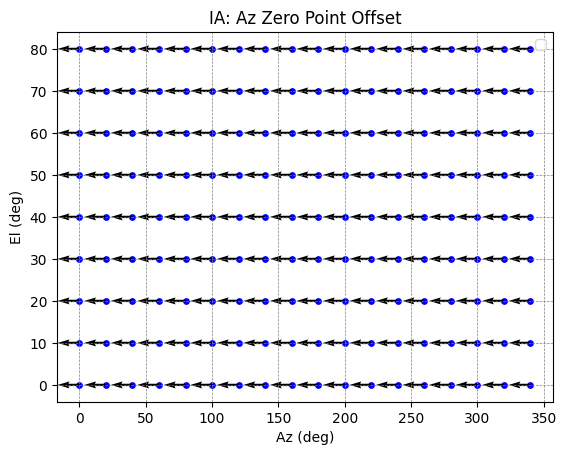

In [24]:
#plot constant of az term
plot_term(AZ, EL,
          a[0]*fa0,
          b[0]*fb0,
          "IA: Az Zero Point Offset")

/tmp/ipykernel_1616/4137341377.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


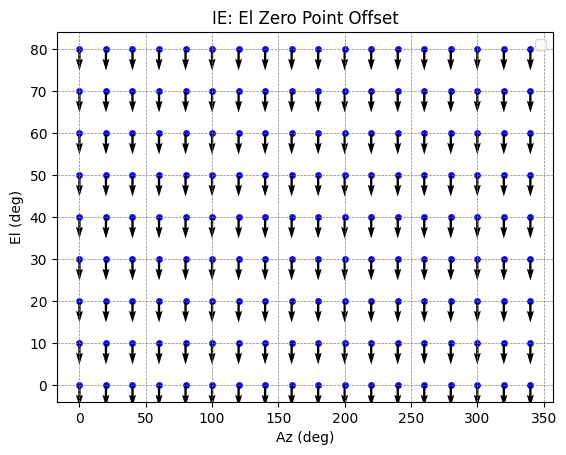

In [25]:
#plot constant of el term
plot_term(AZ, EL,
          a[1]*fa1,
          b[1]*fb1,
          "IE: El Zero Point Offset")

/tmp/ipykernel_1616/4137341377.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


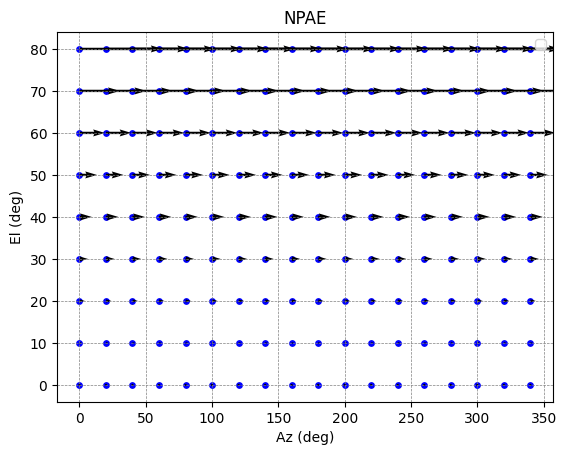

In [26]:
#NPAE
plot_term(AZ, EL,
          a[2]*fa2,
          b[2]*fb2,
          "NPAE")

/tmp/ipykernel_1616/4137341377.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


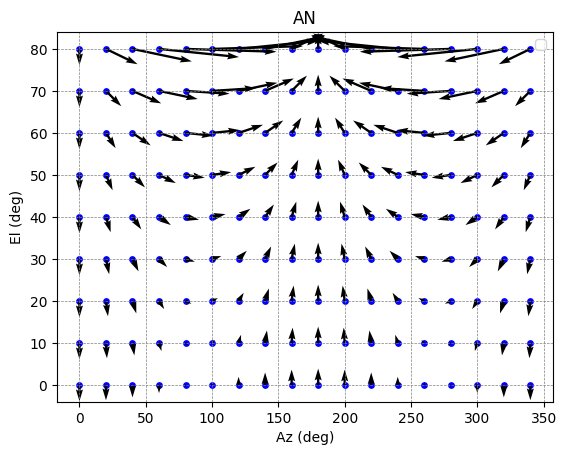

In [27]:
#AN
plot_term(AZ, EL,
          a[3]*fa3,
          b[3]*fb3,
          "AN")

/tmp/ipykernel_1616/4137341377.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


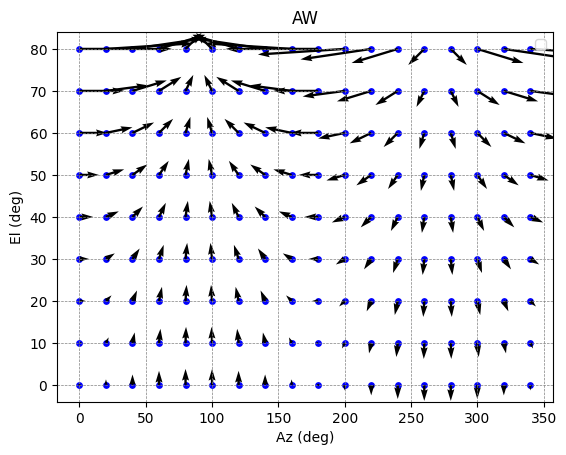

In [28]:
#AW
plot_term(AZ, EL,
          a[4]*fa4,
          b[4]*fb4,
          "AW")

/tmp/ipykernel_1616/4137341377.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


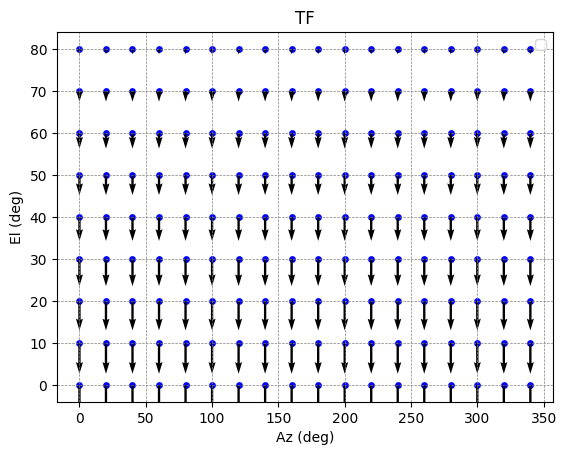

In [29]:
#TF
plot_term(AZ, EL,
          a[5]*fa5,
          b[5]*fb5,
          "TF")

/tmp/ipykernel_1616/4137341377.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


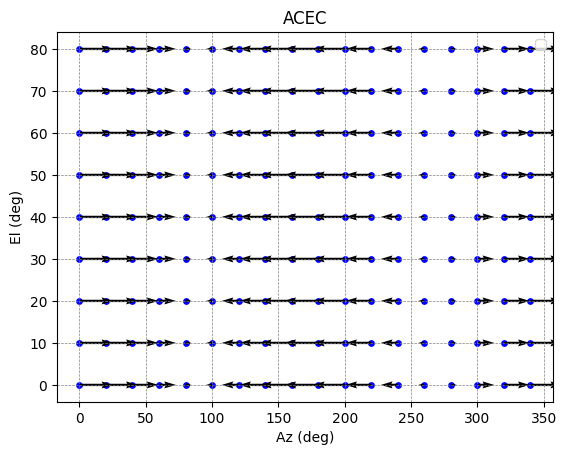

In [30]:
#ACEC
plot_term(AZ, EL,
          a[6]*fa6,
          b[6]*fb6,
          "ACEC")

/tmp/ipykernel_1616/4137341377.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


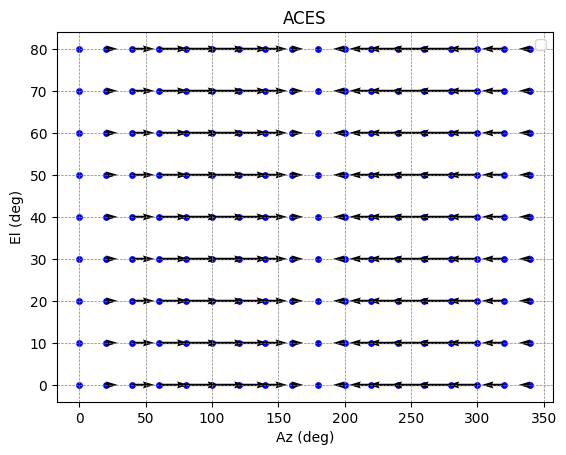

In [31]:
#ACES
plot_term(AZ, EL,
          a[7]*fa7,
          b[7]*fb7,
          "ACES")